# 5. Heterogeneity and Downside Risk

Notebook 4 checked whether the replay leader remains credible under support-aware OPE diagnostics. Notebook 5 asks the next risk question: does the favorable average evidence hide segment-level downside?

This notebook does not rerun OPE. It reads the heterogeneity and downside-risk artifacts produced by notebook 4 and turns them into the paper-facing segment diagnostic. The focus is the priority policy, but the notebook also compares downside summaries across the candidate set.


## What This Notebook Creates

Inputs from notebook 4:

- `metadata/advanced_policy_heterogeneity.csv`
- `metadata/advanced_policy_heterogeneity_summary.csv`
- `metadata/advanced_policy_downside_risk.csv`
- `metadata/marketplace_scorecard.csv`
- `metadata/reserve_policy_registry.csv`

Generated paper figure:

- `artifacts/figures/08_segment_heterogeneity.png`

The notebook also displays two diagnostic tables:

- worst segment cells for the priority policy,
- downside-risk comparison across shortlisted policies.

These tables are useful for interpretation even if only the figure is used in the main manuscript.


## Why Heterogeneity Comes After OPE

Estimator agreement and lower-tail ranking are policy-level diagnostics. They summarize whether a candidate looks attractive on average and under uncertainty. A marketplace policy can still be risky if its gains are concentrated in some parts of the market while other parts suffer. That is why heterogeneity is examined after the OPE ranking.

The heterogeneity artifact estimates segment-level lift across exchange, region, support-cluster, and time-bucket cells. The downside-risk artifact separately summarizes exchange-hour market clusters. These two diagnostics answer related but distinct questions:

1. **Segment heterogeneity:** where does the policy look stronger or weaker across interpretable market slices?
2. **Cluster downside risk:** how much lower-tail risk appears across granular exchange-hour clusters used for uncertainty analysis?

Together they prevent the paper from promoting a policy based only on average lift.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing src/ and pyproject.toml")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Repository root: {REPO_ROOT}")


Repository root: /home/apex/Documents/ranking_sys/notebooks/writing/ads_marketplace_auction_experimentation/marketplace-policies-code


In [2]:
from IPython.display import Image, display

from checks import ArtifactRepository
from config import PaperConfig, ProjectPaths
from figures import FigureRenderer, policy_label
from progress import ProgressLogger


In [3]:
SOURCE_ROOT = REPO_ROOT / "artifacts" / "workspace"
OUTPUT_ROOT = REPO_ROOT / "artifacts"

paths = ProjectPaths.from_cli(SOURCE_ROOT, OUTPUT_ROOT)
paths.ensure_output_dirs()
repository = ArtifactRepository(paths)
repository.require_layout()
progress = ProgressLogger(enabled=True)
config = PaperConfig()

required = [
    paths.metadata_dir / "advanced_policy_heterogeneity.csv",
    paths.metadata_dir / "advanced_policy_heterogeneity_summary.csv",
    paths.metadata_dir / "advanced_policy_downside_risk.csv",
    paths.metadata_dir / "marketplace_scorecard.csv",
    paths.metadata_dir / "reserve_policy_registry.csv",
]
missing = [path.relative_to(REPO_ROOT) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Run notebooks/4_ope_estimator_diagnostics.ipynb first. "
        f"Missing: {missing}"
    )

print("Required heterogeneity and downside-risk artifacts are present.")


Required heterogeneity and downside-risk artifacts are present.


## Load Policy Labels and Heterogeneity Artifacts

The policy registry supplies reader-facing policy labels and policy numbers. The heterogeneity artifacts come from the OPE builder's cross-fitted DR analysis.


In [4]:
policy_registry = repository.read_csv("reserve_policy_registry.csv")[["policy_id", "policy_number", "policy_label"]]
heterogeneity = repository.read_csv("advanced_policy_heterogeneity.csv")
heterogeneity_summary = repository.read_csv("advanced_policy_heterogeneity_summary.csv")
downside = repository.read_csv("advanced_policy_downside_risk.csv")
scorecard = repository.read_csv("marketplace_scorecard.csv")

print(f"Segment-level rows: {len(heterogeneity):,}")
print(f"Policies in heterogeneity summary: {heterogeneity_summary['policy_id'].nunique():,}")
print(f"Priority policy: {config.priority_policy_id}")


Segment-level rows: 510
Policies in heterogeneity summary: 6
Priority policy: hybrid_q75_if_gap_100


## Candidate-Level Heterogeneity Summary

The summary table below compares candidates by the distribution of segment-level DR lift. The two most useful columns for decision support are the 10th percentile segment lift and the negative-segment share. A high average policy with many negative segments is not a clean validation candidate; it may need segmentation, narrower eligibility, or additional guardrails.


In [5]:
heterogeneity_summary_display = (
    heterogeneity_summary.merge(policy_registry, on="policy_id", how="left")
    .assign(reader_label=lambda d: d["policy_label"].fillna(d["policy_id"].map(policy_label)))
    [[
        "policy_number",
        "reader_label",
        "policy_id",
        "segment_cells",
        "p10_segment_dr_lift",
        "median_segment_dr_lift",
        "p90_segment_dr_lift",
        "negative_segment_share",
    ]]
    .sort_values("p10_segment_dr_lift", ascending=False)
)
heterogeneity_summary_display


,policy_number,reader_label,policy_id,segment_cells,p10_segment_dr_lift,median_segment_dr_lift,p90_segment_dr_lift,negative_segment_share
2,P18,Q75 Margin-Gated Floor,hybrid_q75_if_gap_100,85,0.250842,0.522980,0.864699,0.000000
4,P11,Min Positive Floor Q75,min_positive_floor_q75,85,0.141525,0.388990,0.721350,0.035294
0,P8,Add 20 All Floors,add_20_all_floors,85,-0.039363,0.110293,0.330806,0.129412
3,P16,Margin Gap 100 Add 20,margin_gap_100_add_20,85,-0.045995,0.091483,0.347221,0.211765
1,P17,Hybrid Q50 If Gap 50,hybrid_q50_if_gap_50,85,-0.049125,0.099739,0.255549,0.152941
5,P13,Zero And Low Floor To Q50,zero_and_low_floor_to_q50,85,-0.091119,0.082723,0.208451,0.270588


For the priority policy, a favorable lower-tail segment lift and a low negative-segment share strengthen the case that average OPE evidence is not hiding obvious segment-level harm. This still does not prove launch readiness, because segment definitions are observational and the public logs do not reveal live response under changed floors.


## Worst Segment Cells for the Priority Policy

The table below focuses on the weakest observed segment cells for the priority policy. These are the cells an operator would inspect first before deciding how to design a validation test. If the weakest cells are still positive, the policy looks more robust. If some are negative, the policy may need segment-specific exclusions or a more conservative test design.


In [6]:
priority_segments = heterogeneity.loc[heterogeneity["policy_id"].eq(config.priority_policy_id)].copy()
if priority_segments.empty:
    raise ValueError(f"No segment heterogeneity rows found for {config.priority_policy_id}")

priority_segments["segment_label"] = (
    priority_segments["segment_type"].astype(str) + "=" + priority_segments["segment_value"].astype(str)
)
worst_priority_segments = priority_segments.sort_values("segment_dr_lift", ascending=True).head(15)
worst_priority_segments[[
    "segment_type",
    "segment_value",
    "segment_rows",
    "segment_share",
    "segment_dr_lift",
    "segment_structural_lift",
]]


,segment_type,segment_value,segment_rows,segment_share,segment_dr_lift,segment_structural_lift
324,support_cluster,3|124|0|0,3953,0.016471,0.076327,0.490355
144,region,344,1690,0.007042,0.123308,0.476802
246,support_cluster,2|1|2|0,1093,0.004554,0.162752,0.484815
384,support_cluster,3|275|0|0,2069,0.008621,0.174870,0.548481
396,support_cluster,3|27|0|0,2594,0.010808,0.184490,0.535356
204,support_cluster,1|216|0|1,1084,0.004517,0.189096,0.187620
210,support_cluster,1|216|1|1,1068,0.004450,0.202388,0.194457
468,support_cluster,3|79|0|0,2680,0.011167,0.240114,0.482811
294,support_cluster,2|80|1|0,1220,0.005083,0.246227,0.629961
138,region,333,5673,0.023637,0.257765,0.486888


## OPE Figure: Segment Heterogeneity

The paper-facing figure shows the largest observed segment cells for the priority policy. The goal is readability: instead of plotting every segment cell, the figure focuses on the large cells that matter most operationally. Bars to the right of zero indicate positive segment-level DR lift; bars to the left would indicate segment-level harm.


Wrote segment heterogeneity figure to artifacts/figures/08_segment_heterogeneity.png


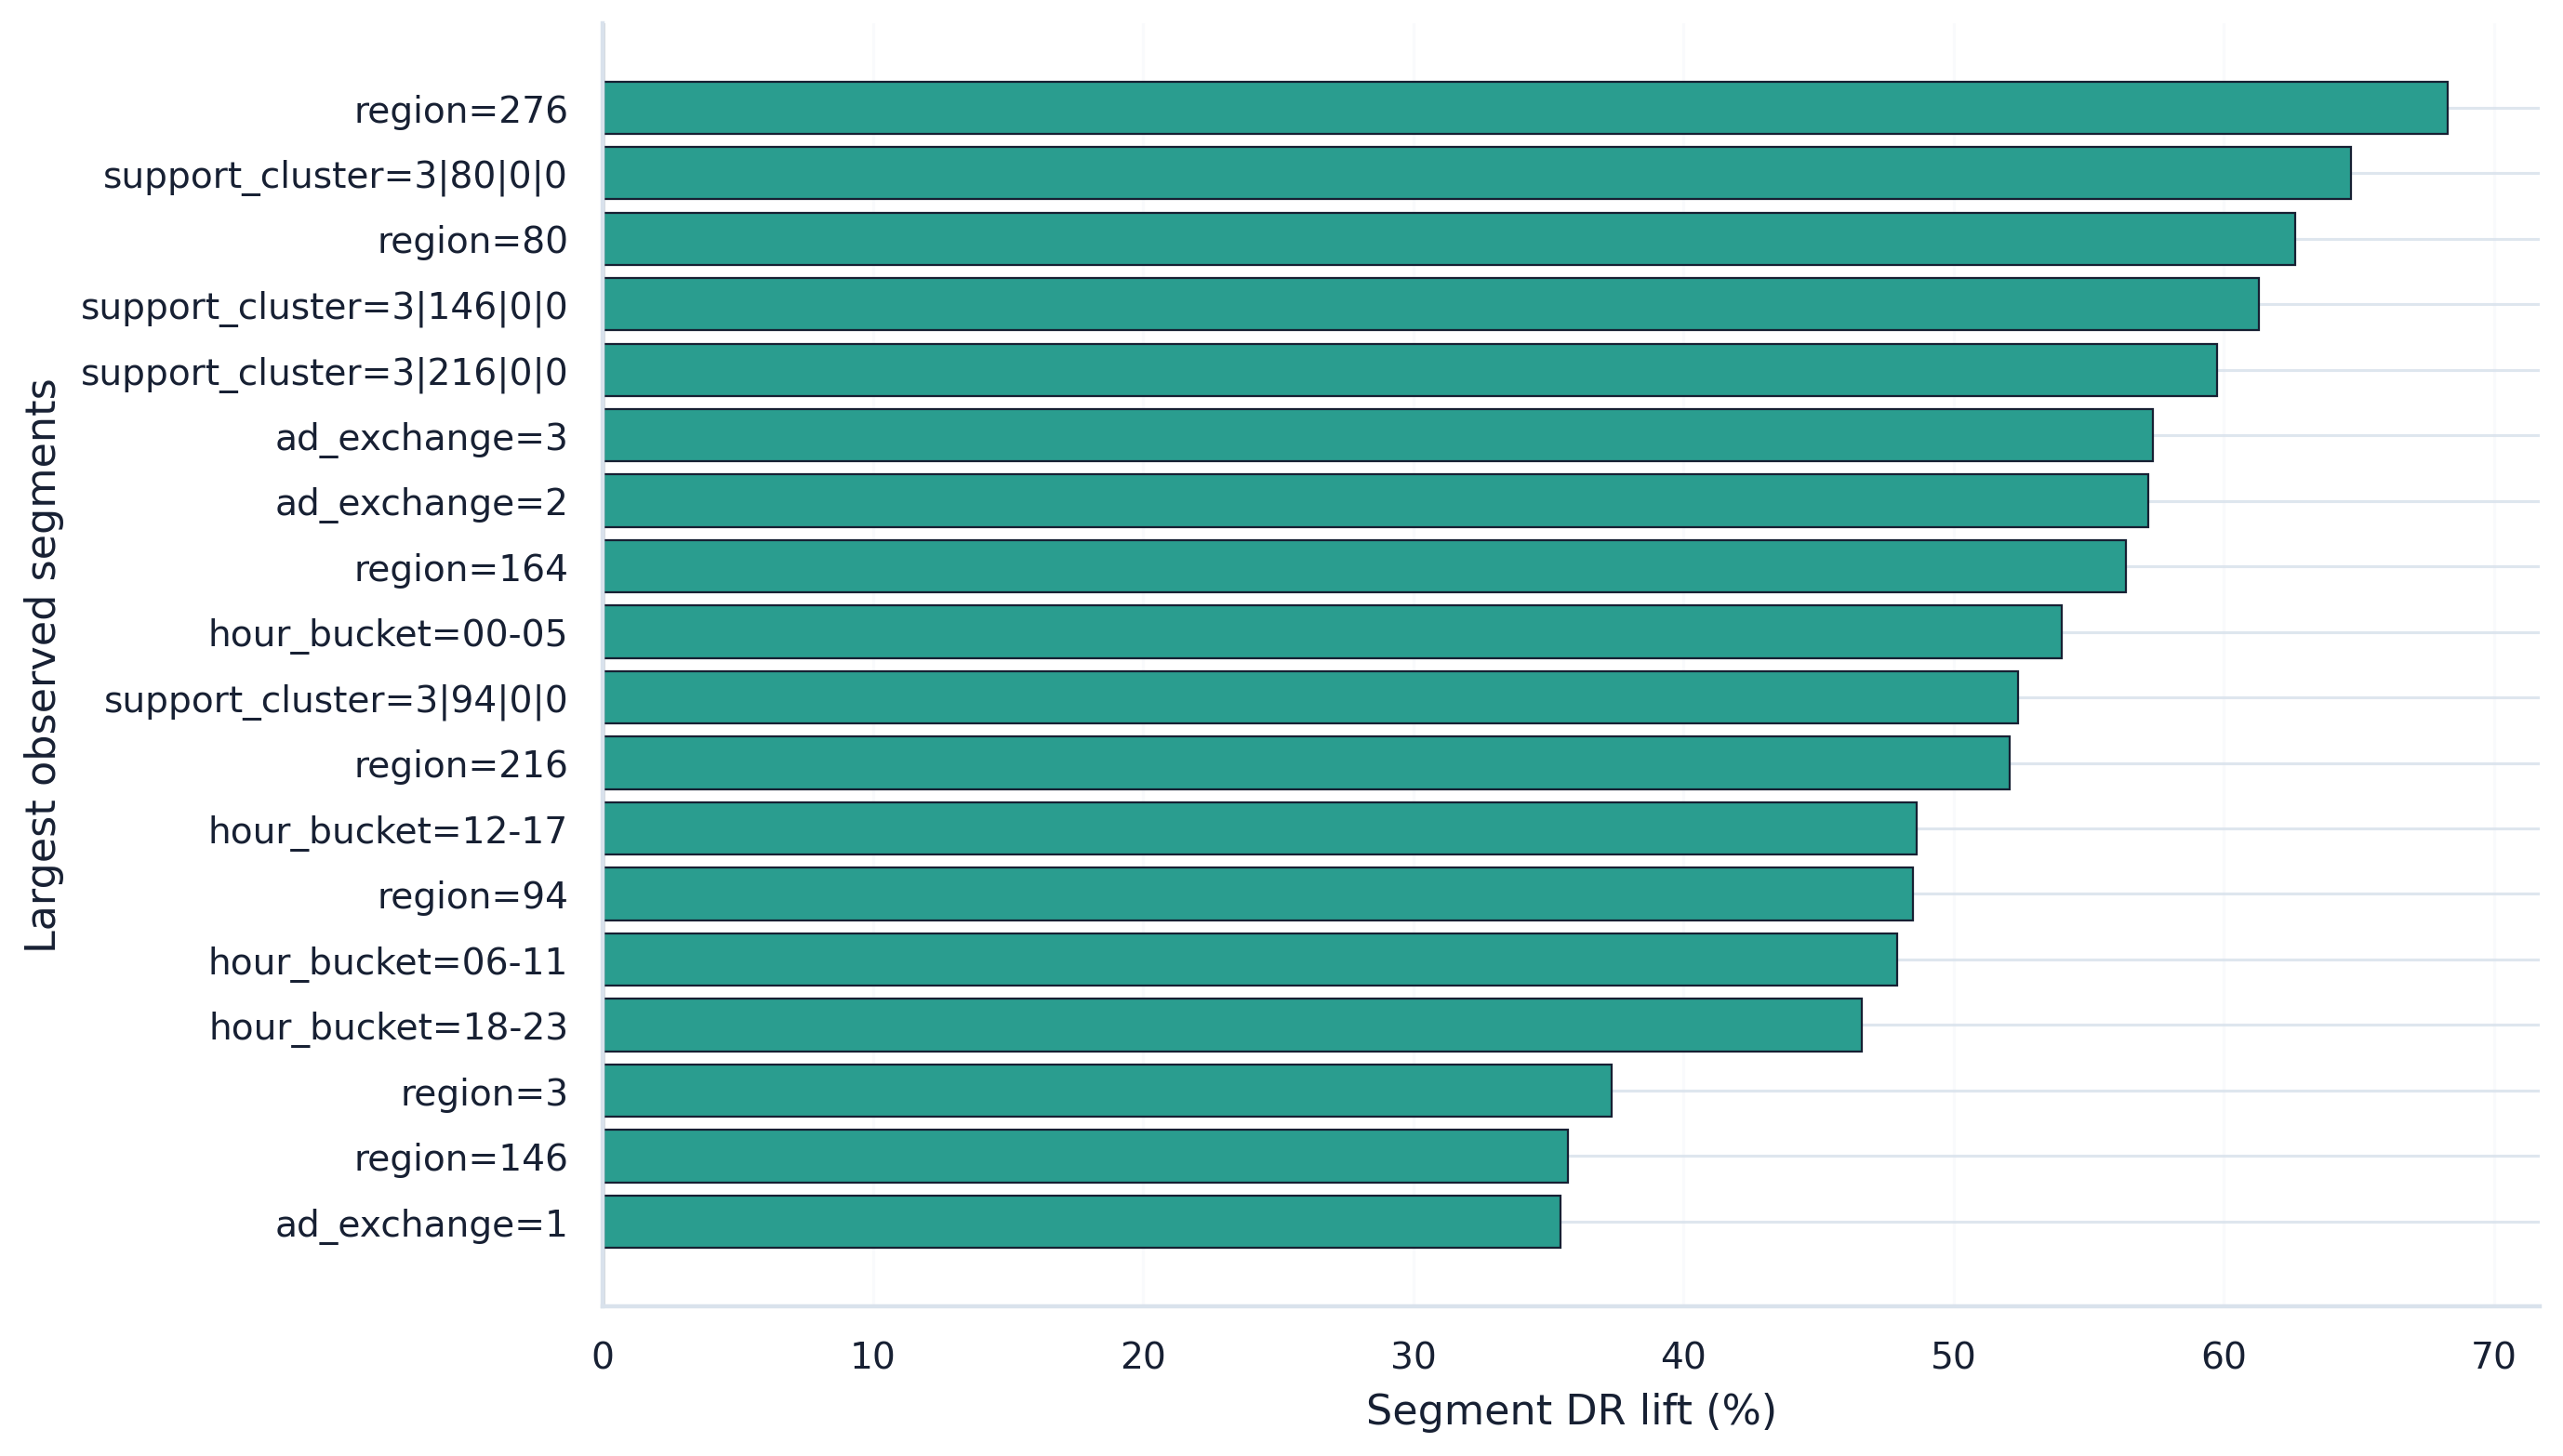

In [7]:
renderer = FigureRenderer(repository, paths.figure_dir, config, progress=progress)
segment_path = renderer.plot_segment_heterogeneity()
print(f"Wrote segment heterogeneity figure to {segment_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(segment_path)))


## Cluster Downside Risk

Segment heterogeneity uses interpretable slices such as exchange, region, support cluster, and hour bucket. The downside-risk table below uses more granular exchange-hour clusters from the bootstrap analysis. This table is closer to the uncertainty logic used by the conservative ranking. It asks how bad the lower tail looks across market clusters, not only across interpretable segment labels.


In [8]:
downside_display = (
    downside.merge(policy_registry, on="policy_id", how="left")
    .assign(reader_label=lambda d: d["policy_label"].fillna(d["policy_id"].map(policy_label)))
    [[
        "policy_number",
        "reader_label",
        "policy_id",
        "eligible_market_clusters",
        "cluster_dr_lift_p10",
        "cluster_dr_lift_cvar10",
        "cluster_dr_negative_share",
        "cluster_structural_lift_p10",
    ]]
    .sort_values("cluster_dr_lift_p10", ascending=False)
)
downside_display


,policy_number,reader_label,policy_id,eligible_market_clusters,cluster_dr_lift_p10,cluster_dr_lift_cvar10,cluster_dr_negative_share,cluster_structural_lift_p10
0,P18,Q75 Margin-Gated Floor,hybrid_q75_if_gap_100,384,-0.008253,-0.274744,0.101562,0.317738
1,P11,Min Positive Floor Q75,min_positive_floor_q75,384,-0.208976,-0.388865,0.205729,0.000000
2,P13,Zero And Low Floor To Q50,zero_and_low_floor_to_q50,384,-0.245634,-0.379019,0.390625,0.036134
3,P17,Hybrid Q50 If Gap 50,hybrid_q50_if_gap_50,384,-0.248544,-0.396703,0.351562,0.036134
4,P16,Margin Gap 100 Add 20,margin_gap_100_add_20,384,-0.253841,-0.397404,0.348958,0.006737
5,P8,Add 20 All Floors,add_20_all_floors,384,-0.277450,-0.376196,0.359375,0.006737


The cluster table is intentionally stricter than the segment figure. It can show lower-tail risk even when the largest interpretable segments look positive. That is useful: the DSS should not hide risk just because the headline policy remains attractive. Instead, it should carry lower-tail risk forward into the final recommendation as a reason for online validation rather than direct launch.


## Scorecard Link

The scorecard incorporates these heterogeneity diagnostics into the broader decision system. The display below shows the priority policy's heterogeneity-related fields alongside the final policy decision.


In [9]:
scorecard.loc[scorecard["policy_id"].eq(config.priority_policy_id), [
    "policy_id",
    "p10_segment_dr_lift",
    "negative_segment_share",
    "heterogeneity_score",
    "cluster_dr_lift_p10",
    "cluster_dr_negative_share",
    "weighted_evidence_score",
    "policy_decision",
    "direct_launch_ready",
    "launch_blocker",
]]


,policy_id,p10_segment_dr_lift,negative_segment_share,heterogeneity_score,cluster_dr_lift_p10,cluster_dr_negative_share,weighted_evidence_score,policy_decision,direct_launch_ready,launch_blocker
0,hybrid_q75_if_gap_100,0.250842,0.0,5,-0.008253,0.101562,4.305,priority_shadow_log_then_switchback,False,missing real known propensities and unvalidate...


## Interpretation for the Paper

This notebook moves the analysis from average policy evidence to distributional risk. The priority policy survives the main OPE diagnostics, but a decision-support system should still ask where the policy is weakest. The segment figure provides an interpretable view of large market slices, while the downside-risk table reports lower-tail behavior over exchange-hour clusters.

The appropriate conclusion is conservative. Favorable segment evidence strengthens the case for validation, but it does not eliminate the need for validation. Negative or weak lower-tail cluster evidence would not necessarily kill the policy; it would shape the experiment design, the guardrail monitoring plan, and possibly the set of eligible market cells. The next notebook can therefore turn to theory and sensitivity: how much unobserved response, interference, or support collapse would be needed to break the offline recommendation?
